In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [28]:
df = df[df['room_type'] == 'Hotel room']

In [29]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared','', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Private half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' hared', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' S half-', '', regex=False)
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')

In [30]:
df = df.dropna(subset=['bathrooms_text'])

<ipython-input-31-45df8fff4c8a>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


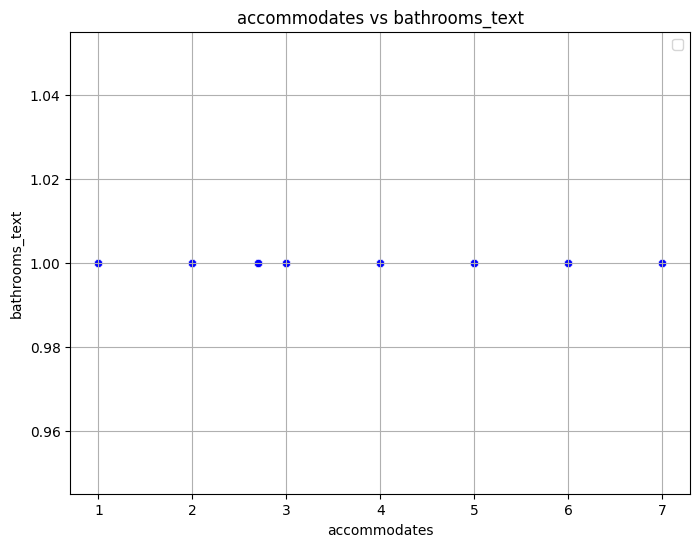

In [31]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='bathrooms_text', x='accommodates',  color = 'blue', data=df)
plt.title('accommodates vs bathrooms_text')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
indep= df[['bathrooms_text']]
dep = df[['accommodates']]

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [34]:
model.fit(indep, dep)

LinearRegression()

In [35]:
type(model)

sklearn.linear_model._base.LinearRegression

In [36]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms_text'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[0.]]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': array([2.54489164])}

In [37]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[0.]]
Intercepto: [2.54489164]
y = [0.]x + [2.54489164]


In [38]:
r2 = model.score(indep, dep)
r2

0.0

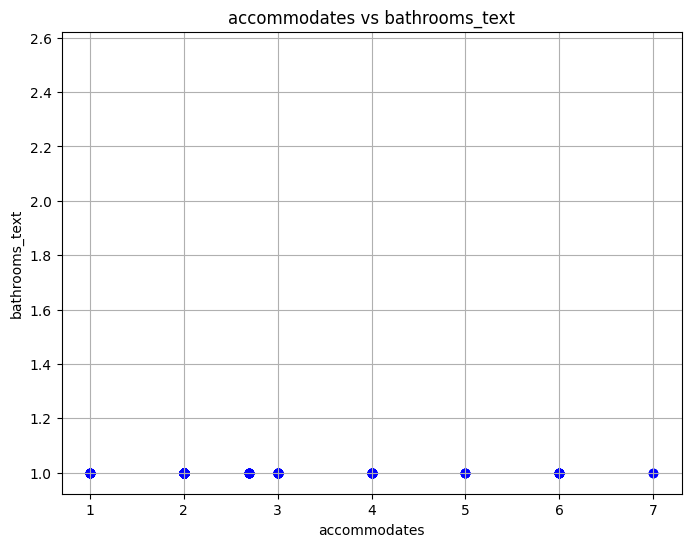

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('accommodates vs bathrooms_text')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.grid(True)
plt.show()

In [40]:
yPred = model.predict(df[['bathrooms_text']])
yPred

array([[2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.54489164],
       [2.544

In [41]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
6,6,city scrape,Comfy bedroom near River pier & BTS Taksin.,This is one of our 'Escape' sleep room : hoste...,"Charoen krung street, River pier, Iconsiam, Su...",Tor,15/10/2010,"Bangkok, Thailand","Hello, my name is Tor, Escape at sathorn terra...",within a few hours,...,4.80,4.77,4.85,4.87,4.85,4.74,4.69,1.27,4.77,2.544892
40,40,previous scrape,Luxury Riverview Teakwood Apartment-Great View...,"Attention: right now we are in Europe, so plea...",The exact location of the property is:<br /><b...,Maam & Hermann,12/04/2012,"Bangkok, Thailand",My thai wife Maam and me are living in this fl...,within an hour,...,4.83,4.91,4.89,4.82,4.89,4.54,4.84,0.80,4.91,2.544892
329,329,city scrape,"Triple room,Near Grand Palace",Feung Nakorn Balcony : <br />Spacious room wit...,Feung Nakorn Balcony is the first and only bou...,Sasi,17/04/2014,"Krung Thep Maha Nakhon, Thailand",Hi we are family-run hostel in the middle of R...,within an hour,...,5.00,4.93,4.87,4.87,4.80,4.93,4.80,0.13,4.93,2.544892
697,697,previous scrape,The Mustang Nero/No.4 The Horse,"This cozy room,The Horse, is 45 sq m.","- ""Joa-Mud-cha"" Thai food (local style)<br />-...",The Mustang Nero,10/04/2015,"Bangkok, Thailand","Hi. My name is Siri, a yoga instructor from Ba...",a few days or more,...,4.80,4.93,4.80,4.91,4.90,4.56,4.71,0.70,4.93,2.544892
707,707,previous scrape,The Mustang Nero/No.3 The Wolf,"This cozy room,The wolf, is 35 sq m.<br /><br ...","- ""Joa-Mud-cha"" Thai food (local style)<br />-...",The Mustang Nero,10/04/2015,"Bangkok, Thailand","Welcome to Bangkok :-)\r\n\r\nHello, we are Ta...",a few days or more,...,4.85,4.91,4.75,4.94,4.94,4.60,4.75,0.70,4.91,2.544892


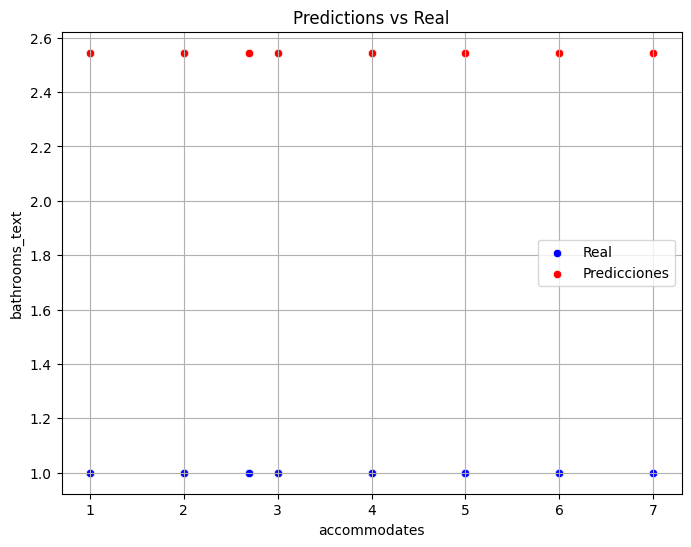

In [42]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='accommodates', y='bathrooms_text', color='blue', data=df, label='Real')
sns.scatterplot(x='accommodates', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
coefDe = model.score(indep, dep)
coefDe

0.0

In [44]:
coefCo = np.sqrt(coefDe)
coefCo

0.0